In [1]:
#!/bin/bash
!curl -L -o hotel-booking-demand.zip\
  https://www.kaggle.com/api/v1/datasets/download/jessemostipak/hotel-booking-demand

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1277k  100 1277k    0     0  2564k      0 --:--:-- --:--:-- --:--:-- 2564k


In [2]:
!unzip /content/hotel-booking-demand.zip

Archive:  /content/hotel-booking-demand.zip
  inflating: hotel_bookings.csv      


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/hotel_bookings.csv')

In [5]:
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [6]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [8]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [10]:
df['adr'].describe().T

,adr
count,119390.000000
mean,101.831122
std,50.535790
min,-6.380000
25%,69.290000
50%,94.575000
75%,126.000000
max,5400.000000


In [19]:
df.shape

(119390, 32)

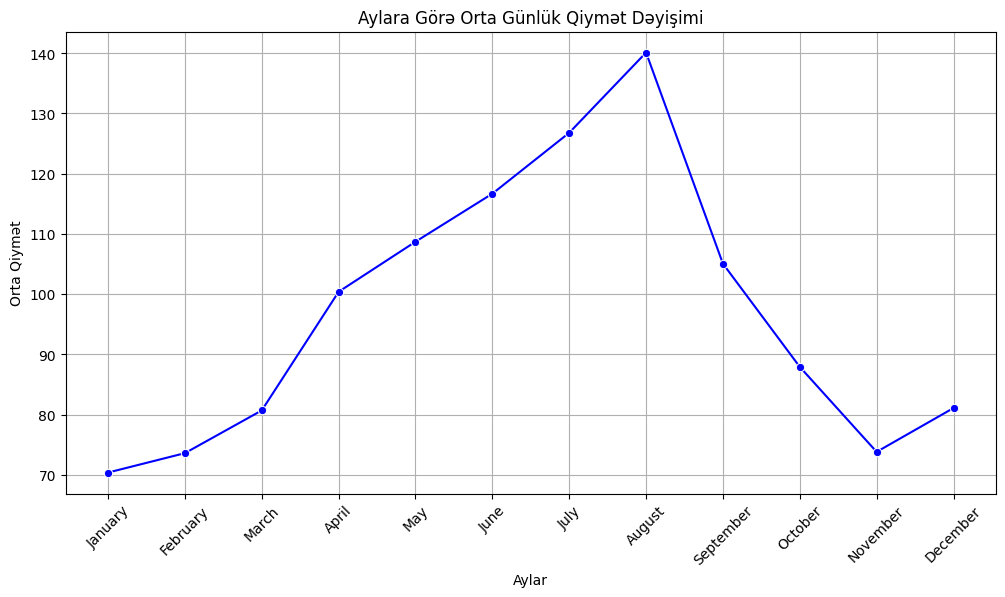

In [18]:
months_order = ['January', 'February', 'March', 'April', 'May', 'June',
                'July', 'August', 'September', 'October', 'November', 'December']

df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=months_order, ordered=True)

plt.figure(figsize=(12, 6))
sns.lineplot(x='arrival_date_month', y='adr', data=df, marker='o', color='b', errorbar=None)

plt.title('Aylara Görə Orta Günlük Qiymət Dəyişimi')
plt.xlabel('Aylar')
plt.ylabel('Orta Qiymət')
plt.grid(True)
plt.xticks(rotation=45)

plt.show()

/tmp/ipykernel_11847/68610704.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='hotel', y='adr', data=df, palette='Set2')


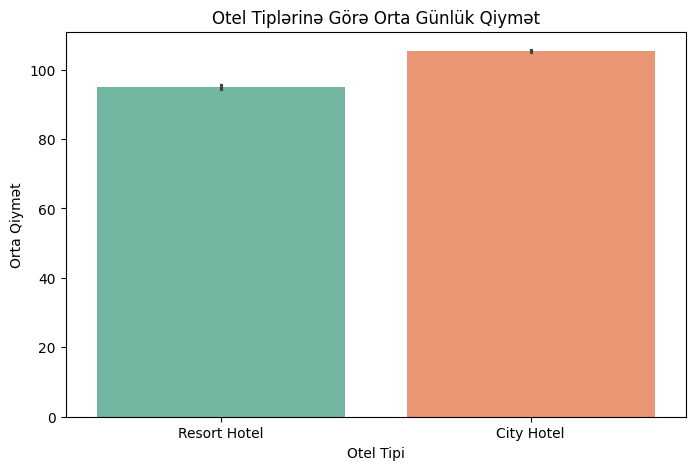

In [14]:
plt.figure(figsize=(8, 5))
sns.barplot(x='hotel', y='adr', data=df, palette='Set2')

plt.title('Otel Tiplərinə Görə Orta Günlük Qiymət')
plt.xlabel('Otel Tipi')
plt.ylabel('Orta Qiymət')
plt.show()

/tmp/ipykernel_11847/3528933012.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='reserved_room_type', y='adr', data=df, order=rooms, palette='viridis')


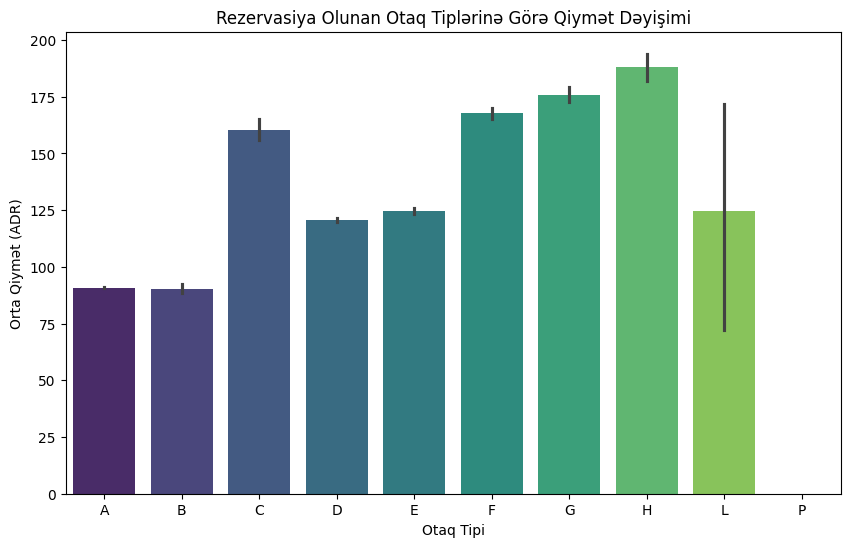

In [15]:
plt.figure(figsize=(10, 6))

rooms = sorted(df['reserved_room_type'].unique())

sns.barplot(x='reserved_room_type', y='adr', data=df, order=rooms, palette='viridis')

plt.title('Rezervasiya Olunan Otaq Tiplərinə Görə Qiymət Dəyişimi')
plt.xlabel('Otaq Tipi')
plt.ylabel('Orta Qiymət (ADR)')
plt.show()

In [20]:
df = df[df['adr'] > 0]

Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df = df[(df['adr'] >= lower_limit) & (df['adr'] <= upper_limit)]

print(df.shape)

(113380, 32)


In [21]:
df = df[(df['adults'] + df['children'] + df['babies']) > 0]

print(df.shape)

(113345, 32)


In [22]:
df['children'] = df['children'].fillna(0)

In [23]:
df['country'] = df['country'].fillna('Unknown')

In [24]:
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

In [25]:
df.isna().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [26]:
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

df['total_guests'] = df['adults'] + df['children'] + df['babies']

df['is_room_assigned_same'] = (df['reserved_room_type'] == df['assigned_room_type']).astype(int)

print(df[['total_stay', 'total_guests', 'is_room_assigned_same', 'is_canceled']].head())

   total_stay  total_guests  is_room_assigned_same  is_canceled
2           1           1.0                      0            0
3           1           1.0                      1            0
4           2           2.0                      1            0
5           2           2.0                      1            0
6           2           2.0                      1            0


In [27]:
drop_columns = ['reservation_status', 'reservation_status_date', 'assigned_room_type', 'country']

df = df.drop(columns=drop_columns)

In [28]:
df = pd.get_dummies(df, columns=['hotel', 'arrival_date_month', 'meal', 'market_segment',
                                                 'distribution_channel', 'deposit_type', 'customer_type', 'reserved_room_type'],
                    drop_first=True)

In [30]:
df.head()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,customer_type_Transient,customer_type_Transient-Party,reserved_room_type_B,reserved_room_type_C,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_L
2,0,7,2015,27,1,0,1,1,0.0,0,...,True,False,False,False,False,False,False,False,False,False
3,0,13,2015,27,1,0,1,1,0.0,0,...,True,False,False,False,False,False,False,False,False,False
4,0,14,2015,27,1,0,2,2,0.0,0,...,True,False,False,False,False,False,False,False,False,False
5,0,14,2015,27,1,0,2,2,0.0,0,...,True,False,False,False,False,False,False,False,False,False
6,0,0,2015,27,1,0,2,2,0.0,0,...,True,False,False,True,False,False,False,False,False,False


In [32]:
from sklearn.model_selection import train_test_split

In [33]:
X = df.drop(columns=['adr'])
y = df['adr']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = .2,
    random_state = 42
)

In [35]:
X_train.shape

(90676, 61)

In [36]:
X_test.shape

(22669, 61)

In [37]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [38]:
model = DecisionTreeRegressor(random_state=42)

In [39]:
model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [41]:
y_pred = model.predict(X_test)

In [42]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [43]:
print(mae)
print(mse)
print(rmse)
print(r2)

7.056003717862274
251.72745691143288
15.865921243704472
0.8323385319601219


In [45]:
y_train_pred = model.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)

In [47]:
r2_train #Overfitting

0.9989853304158935

In [48]:
new_model = DecisionTreeRegressor(max_depth=10, min_samples_split=10, random_state=42)

In [49]:
new_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=10, min_samples_split=10, random_state=42)

In [50]:
y_train_pred= new_model.predict(X_train)
y_test_pred = new_model.predict(X_test)

In [51]:
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

In [52]:
print(r2_train)
print(r2_test)

0.7155609202790347
0.6918573045853865
